# A comprehensive MicrobioLink run with optional modules (notebook)

This notebook drives the **whole** MicrobioLink pipeline from Python, wiring the
modules together with the public API. It runs every stage &mdash; membrane
filtering, sequence and domain download, domain&ndash;domain and
domain&ndash;motif prediction, the confidence filters, network propagation and
enrichment &mdash; in **both the forward and reverse directions**.

It is the most complete of the four tutorials. If you are running MicrobioLink
for the first time, the shorter [default notebook](t2_api_basic.md) is a gentler
start; the two command-line tutorials ([comprehensive](t3_cli_full.md),
[default](t4_cli_basic.md)) run the same steps from the terminal.

**The biology.** We predict interactions between *Bacteroides thetaiotaomicron*
outer-membrane-vesicle (OMV) proteins and human colonic enterocyte (BEST4)
proteins, in the context of Crohn's disease &mdash; the published MicrobioLink
case study, cut down to a small, fast example dataset (see
[`data/README.md`](data/README.md)).

**Before you start**

- Install MicrobioLink with the optional extras this notebook uses:
  `pip install "microbiolink[idr,tiedie,enrichment]"` (see
  [Get Started](../get-started.md#optional-extras)).
- The pipeline concepts &mdash; what each module does, and what *forward* and
  *reverse* mean &mdash; are defined in [Pipeline Concepts](../concepts.md); this
  notebook links back there rather than re-explaining them.
- Several stages fetch data live (UniProt, Pfam, OmniPath, Enrichr), so the exact
  counts can drift slightly as those resources are updated. The local core
  (IDR &rarr; Monte Carlo) is deterministic: it uses the **`iupred`** disorder
  method and Monte-Carlo **`seed=0`**, so it reproduces on rerun.

## Setup

Everything the notebook needs from the public API, plus the path to the example
dataset. The notebook is written to be run from the `docs/tutorials/` directory,
so the data lives in `data/` next to it.

In [1]:
%matplotlib inline
import logging
from pathlib import Path

import pandas as pd

# The live-lookup libraries (mygene/biothings, gget) log a line per query. They
# re-assert their own log level when imported, so a plain setLevel does not stick;
# attach a filter that drops their records and stop them propagating to the root.
class _DropRecords(logging.Filter):
    def filter(self, record):
        return False

for _noisy in ("biothings.client", "gget", "gget.utils", "mygene"):
    _lg = logging.getLogger(_noisy)
    _lg.addFilter(_DropRecords())
    _lg.propagate = False
    _lg.setLevel(logging.ERROR)

from microbiolink.workflow.zscore_filter import filter_counts_by_zscore
from microbiolink.workflow.membrane_filter import filter_membrane_proteins
from microbiolink.workflow.fasta_download import download_fasta
from microbiolink.workflow.domain_download import download_domains
from microbiolink.workflow.ddi import predict_domain_domain_interactions
from microbiolink.workflow.dmi import predict_domain_motif_interactions
from microbiolink.workflow.idr_filter import filter_by_disorder
from microbiolink.workflow.monte_carlo import filter_by_monte_carlo
from microbiolink.workflow.tiedie import run_tiedie_pipeline
from microbiolink.workflow.enrichment import run_enrichment_analysis
from microbiolink.utils.fasta import read_fasta_sequences

DATA = Path("data")
WORK = Path("t1_work")
WORK.mkdir(exist_ok=True)

## The dataset

The example dataset is *inputs only* &mdash; identifier lists and transcriptomics,
with sequences and domains fetched live. The two protein lists are the starting
point for the interaction prediction.

In [2]:
human_ids = pd.read_csv(DATA / "human_proteins.csv")["uniprot_id"].tolist()
bacterial_ids = pd.read_csv(DATA / "bacterial_proteins.csv")["uniprot_id"].tolist()

print(f"{len(human_ids)} human proteins, {len(bacterial_ids)} bacterial (OMV) proteins")
pd.read_csv(DATA / "human_proteins.csv").head()

276 human proteins, 243 bacterial (OMV) proteins


,uniprot_id
0,A1A5B4
1,B4DS77
2,O00463
3,O00519
4,O00548


## Module 1 &mdash; Z-score filter (transcriptomics entry point)

The [Z-score filter](../concepts.md#1-z-score-filter) is how you turn a raw host
**count matrix** into the set of *expressed* genes a run is built on. Our curated
dataset already provides the expressed-gene list (`expressed_counts.csv`), so the
main path below does not need this step &mdash; but here is the mechanic on the
count matrix, so you can see what it does when you start from raw counts. It keeps
only values whose per-column z-score clears the cut-off; everything else becomes
`NaN`.

In [3]:
counts = pd.read_csv(DATA / "expressed_counts.csv", index_col=0)
filtered = filter_counts_by_zscore(counts, zscore_threshold=2.0)

kept = filtered.dropna(how="all")
print(f"{len(counts)} genes in -> {len(kept)} genes above the z-score cut-off")
kept.head()

10994 genes in -> 572 genes above the z-score cut-off


,expression
Gene,
AURKAIP1,3.416133
RPL22,8.967916
PARK7,2.299261
MINOS1,2.876272
NBL1,2.485037


## Module 2 &mdash; Membrane filter

The [membrane filter](../concepts.md#2-membrane-protein-filter) narrows each
protein set to the proteins that can plausibly meet a partner from the other
organism. The two species use different evidence, and here they are treated
differently on purpose:

- **Human** proteins are filtered through OmniPath's *Intercell* classification
  &mdash; we keep the plasma-membrane, secreted and cell-surface categories.
- **Bacterial** OMV proteins are used **directly, without a location filter**.
  They are already an experimentally isolated outer-membrane-vesicle fraction, so
  the fractionation *is* the localization step; in UniProt they carry essentially
  no subcellular-location annotation, so a text filter would wrongly drop the real
  hits (see [`data/README.md`](data/README.md)).

In [4]:
HUMAN_LOCATIONS = [
    "plasma_membrane_transmembrane",
    "plasma_membrane_peripheral",
    "secreted",
    "cell_surface",
]

membrane_human = filter_membrane_proteins(human_ids, "uniprot", "human", HUMAN_LOCATIONS)
human_surface = membrane_human["uniprot_id"].tolist()

print(f"human: {len(human_ids)} -> {len(human_surface)} surface/secreted proteins")
print(f"bacterial: {len(bacterial_ids)} OMV proteins used directly")
membrane_human.head()

human: 276 -> 270 surface/secreted proteins
bacterial: 243 OMV proteins used directly


,uniprot_id,location_annotation
0,A1A5B4,cell_surface;plasma_membrane_transmembrane
1,B4DS77,cell_surface;plasma_membrane_transmembrane
2,O00463,plasma_membrane_transmembrane
3,O00519,plasma_membrane_transmembrane
4,O00548,cell_surface;plasma_membrane_transmembrane;sec...


## Module 3 &mdash; FASTA download

[FASTA download](../concepts.md#3-fasta-download) retrieves the protein sequences
from UniProt. The motif search in Module 6 needs the sequences of whichever
species carries the motif, so for a *both-directions* run we download both.

In [5]:
fasta_paths = download_fasta(
    WORK,
    human_identifiers=human_surface,
    human_id_type="uniprot",
    microbial_identifiers=bacterial_ids,
    microbial_id_type="uniprot",
)
human_sequences = read_fasta_sequences(fasta_paths["human"])
bacterial_sequences = read_fasta_sequences(fasta_paths["microbial"])

print(f"{len(human_sequences)} human and {len(bacterial_sequences)} bacterial sequences")

270 human and 243 bacterial sequences


## Module 4 &mdash; Domain download

[Domain download](../concepts.md#4-domain-download) fetches the Pfam domains each
protein carries and returns a `pfam_id -> [uniprot_id, ...]` mapping per species
&mdash; exactly the shape the DDI and DMI lookups consume.

In [6]:
domains = download_domains(
    human_identifiers=human_surface,
    human_id_type="uniprot",
    microbial_identifiers=bacterial_ids,
    microbial_id_type="uniprot",
)
human_domains = domains["human"]
bacterial_domains = domains["microbial"]

print(f"{len(human_domains)} human Pfam domains, {len(bacterial_domains)} bacterial Pfam domains")

328 human Pfam domains, 323 bacterial Pfam domains


## Module 5 &mdash; Domain&ndash;domain interactions (DDI)

[DDI](../concepts.md#5-domain-domain-interactions-ddi) predicts interactions
directly between the two species' domains, using the packaged 3did and DOMINE
resources. It is a *side branch*: an optional extra evidence source that TieDie
can merge in later.

In [7]:
ddi = predict_domain_domain_interactions(bacterial_domains, human_domains)
print(f"{len(ddi)} predicted domain-domain interactions")
ddi.head()

1848 predicted domain-domain interactions


,bacterial_uniprot_id,bacterial_pfam_domain,human_uniprot_id,human_pfam_domain,resource
0,Q8A0L4,PF00004,P46531,PF00023,DOMINE_hc
1,Q8A0L4,PF00004,Q04721,PF00023,DOMINE_hc
2,Q8A0L4,PF17862,P46531,PF00023,3did
3,Q8A0L4,PF17862,Q04721,PF00023,3did
4,Q8A0L4,PF17862,P46531,PF12796,3did


## Module 6 &mdash; Domain&ndash;motif interactions (DMI), both directions

[DMI](../concepts.md#6-domain-motif-interactions-dmi) is the core prediction. We
run `mode="both"`, so the table carries a `dmi_type` column separating the two
[directions](../concepts.md#forward-vs-reverse-microbiolink):

- **forward** &mdash; bacterial domain &rarr; human motif (motifs searched in the
  human sequences),
- **reverse** &mdash; human domain &rarr; bacterial motif (motifs searched in the
  bacterial sequences).

In [8]:
dmi = predict_domain_motif_interactions(
    "both",
    human_sequences=human_sequences,
    bacterial_domains=bacterial_domains,
    bacterial_sequences=bacterial_sequences,
    human_domains=human_domains,
)
print(f"{len(dmi)} DMIs total")
print(dmi["dmi_type"].value_counts())
dmi.head()

63387 DMIs total
dmi_type
reverse    44283
forward    19104
Name: count, dtype: int64


,dmi_type,bacterial_uniprot_id,bacterial_annotation,human_uniprot_id,human_annotation,start,end,resource
0,forward,Q8A0Y2,PF00082,A1A5B4,CLV_PCSK_PC1ET2_1|CLV_PCSK_KEX2_1,285,288,ELM
1,forward,Q8A0Y2,PF00082,A1A5B4,CLV_PCSK_SKI1_1,73,78,ELM
2,forward,Q8A0Y2,PF00082,A1A5B4,CLV_PCSK_SKI1_1,90,95,ELM
3,forward,Q8A0Y2,PF00082,A1A5B4,CLV_PCSK_SKI1_1,167,172,ELM
4,forward,Q8A0Y2,PF00082,A1A5B4,CLV_PCSK_SKI1_1,185,190,ELM


## Module 7 &mdash; IDR filter

Short linear motifs bind through **disordered** regions, so the
[IDR filter](../concepts.md#7-intrinsic-disorder-region-idr-prediction) keeps only
the DMIs whose motif sits in a disordered, binding-competent stretch. We use the
deterministic `iupred` method with a disorder and binding cut-off of `0.5`.

In [9]:
idr = filter_by_disorder(
    dmi,
    human_sequences,
    bacterial_sequences,
    method="iupred",
    disorder_cutoff=0.5,
    binding_cutoff=0.5,
)
print(f"{len(idr)} DMIs pass the IDR filter")
print(idr["dmi_type"].value_counts())
idr.head()

1667 DMIs pass the IDR filter
dmi_type
forward    1463
reverse     204
Name: count, dtype: int64


,dmi_type,bacterial_uniprot_id,bacterial_annotation,human_uniprot_id,human_annotation,start,end,resource,disordered_score,binding_score,combined_score
0,forward,Q8A5K0,PF00595,O00548,LIG_PDZ_Class_1,717,723,ELM,0.709450,0.522649,0.616050
1,forward,Q8A5K0,PF00595,O00548,3DID_PDZ_LIG_0-49,720,723,3did,0.801067,0.512617,0.656842
2,forward,Q8A5K0,PF00595,O00548,3DID_PDZ_LIG_4-6,651,654,3did,0.571900,0.570819,0.571359
3,forward,Q8A0Y2,PF00082,O14672,CLV_PCSK_PC1ET2_1|CLV_PCSK_KEX2_1,720,723,ELM,0.922600,0.575922,0.749261
4,forward,Q89YL8,PF00754,O14672,LIG_NRP_CendR_1,746,748,ELM,0.994150,0.996541,0.995345


## Module 8 &mdash; Monte Carlo over-representation test

The [Monte Carlo filter](../concepts.md#8-monte-carlo-simulation) adds a
significance test: is each motif *over-represented* in its disordered region
compared with the disordered proteome's amino-acid composition? P-values are
Benjamini&ndash;Hochberg corrected and filtered at `alpha=0.05`. We fix
`seed=0` so the result is reproducible.

In [10]:
monte_carlo = filter_by_monte_carlo(
    idr,
    human_sequences,
    bacterial_sequences,
    method="iupred",
    disorder_cutoff=0.5,
    iterations=1000,
    alpha=0.05,
    seed=0,
)
print(f"{len(monte_carlo)} DMIs pass the Monte Carlo test")
print(monte_carlo["dmi_type"].value_counts())
monte_carlo.head()

207 DMIs pass the Monte Carlo test
dmi_type
forward    113
reverse     94
Name: count, dtype: int64


,dmi_type,bacterial_uniprot_id,bacterial_annotation,human_uniprot_id,human_annotation,start,end,resource,disordered_score,binding_score,combined_score,monte_carlo_hits,monte_carlo_pvalue,monte_carlo_qvalue,passes_monte_carlo
0,forward,Q8A5K0,PF00595,O00548,3DID_PDZ_LIG_0-49,720,723,3did,0.801067,0.512617,0.656842,2,0.002997,0.045972,True
1,forward,Q8A0L4,PF00004,O94985,3DID_AAA_LIG_0-9,924,934,3did,0.996410,0.960024,0.978217,0,0.000999,0.028605,True
2,forward,Q8A470,PF04997,O94985,3DID_RNA_pol_Rpb1_1_LIG_3-2,924,932,3did,0.995513,0.956707,0.976110,0,0.000999,0.028605,True
3,forward,Q8A470,PF04997,O94985,3DID_RNA_pol_Rpb1_1_LIG_3-2,933,941,3did,0.999850,0.988348,0.994099,0,0.000999,0.028605,True
4,forward,Q8A0L4,PF00004,P04626,3DID_AAA_LIG_0-0|3DID_AAA_LIG_1-1,1158,1165,3did,0.708286,0.825046,0.766666,0,0.000999,0.028605,True


## Module 9 &mdash; TieDie network propagation

[TieDie](../concepts.md#9-tiedie) takes the predicted host targets *into* the host
cell: it connects the human proteins the bacteria engage to the transcription
factors driving the differentially expressed genes, by heat diffusion over a human
signalling network fetched live from OmniPath. We pass the Monte-Carlo DMIs as the
upstream targets and merge in the DDI table as extra evidence.

**On `permute`.** The `permute` argument sets how many permutations TieDie uses to
estimate significance. This tutorial runs **`permute=10`** so it completes quickly
on any machine. For real analyses use the more rigorous **`permute=1000`** &mdash;
on a dataset this size it returns an essentially identical network, but it takes a
few minutes and wants a couple of GB of free memory. TieDie is **not seeded**, so
the network can vary slightly between runs; a higher `permute` makes it more
stable.

In [11]:
degs = pd.read_csv(DATA / "degs.csv")
expressed_genes = pd.read_csv(DATA / "expressed_counts.csv")["Gene"].astype(str).tolist()

network, nodes = run_tiedie_pipeline(
    dmi_table=monte_carlo,
    endpoint_genes=degs,
    expressed_genes=expressed_genes,
    endpoint_value_column=2,   # avg_log2FC is the 2nd column of degs.csv
    ddi_table=ddi,
    permute=10,   # quick; use permute=1000 for real analyses (see note above)
)
print(f"TieDie network: {len(network)} edges / {len(nodes)} nodes")
network.head()

TieDie network: 8639 edges / 2225 nodes


,Target.node,Source.node,Relationship,layer
0,O00548,Q8A5K0,stimulates>,bacteria-bindingprot
3,P04626,Q8A0L4,stimulates>,bacteria-bindingprot
4,P20333,Q8A0L4,stimulates>,bacteria-bindingprot
5,P22607,Q8A0Y6,stimulates>,bacteria-bindingprot
6,P22607,Q8A3C4,stimulates>,bacteria-bindingprot


## Module 10 &mdash; Functional enrichment

Finally, [enrichment](../concepts.md#10-functional-enrichment-analysis) asks which
pathways are over-represented among the engaged host proteins, via Enrichr
(Reactome). It has two entry points, and the comprehensive run uses both:

- **`HMI`** &mdash; the direct host targets from the DMI table, and
- **`TieDIE`** &mdash; every node of the propagated network.

HMI enrichment: 14 significant terms


,rank,path_name,p_val,z_score,combined_score,overlapping_genes,adj_p_val,database
0,1,Regulation Of Signaling By NODAL R-HSA-1433617,0.000085,273.725,2565.305727,"[ACVR1B, ACVR2B]",0.015060,Reactome_2022
1,2,Constitutive Signaling By Aberrant PI3K In Can...,0.000312,26.247596,211.906399,"[CLSTN1, ERBB2, FGFR3]",0.020959,Reactome_2022
2,3,Signaling By TGFB Family Members R-HSA-9006936,0.000355,13.456347,106.880158,"[BMPR2, ACVR1B, ACVR2B, TGFBR1]",0.020959,Reactome_2022
3,4,Signaling By Activin R-HSA-1502540,0.000629,68.39375,504.162923,"[ACVR1B, ACVR2B]",0.026598,Reactome_2022
4,5,Regulation Of FZD By Ubiquitination R-HSA-4641263,0.000767,60.788889,436.052625,"[RNF43, ZNRF3]",0.026598,Reactome_2022


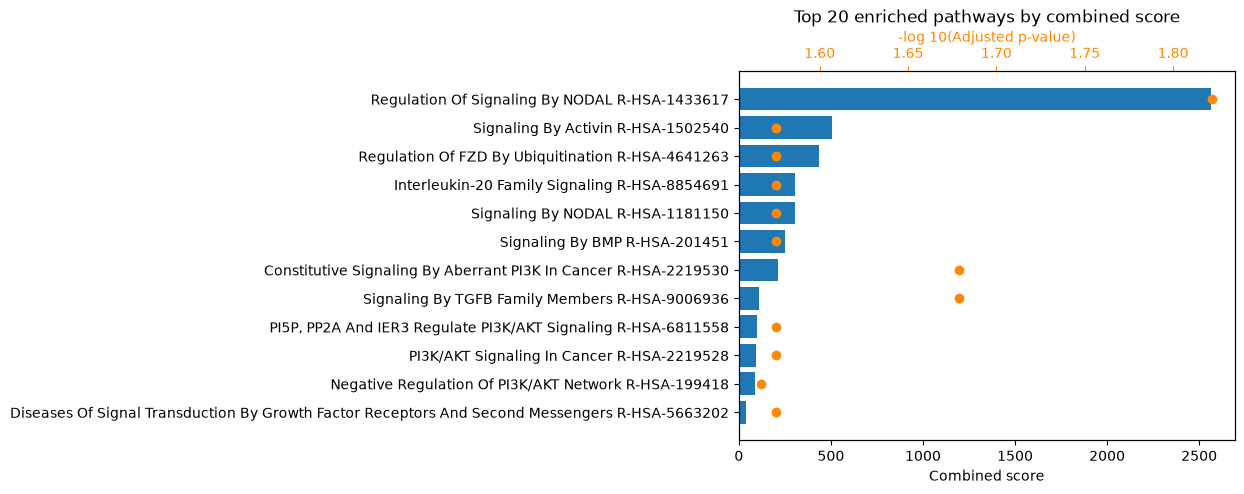

In [12]:
from IPython.display import display

background = pd.read_csv(DATA / "background_genes.csv", header=None)[0].astype(str).tolist()

hmi_results, hmi_figure = run_enrichment_analysis(monte_carlo, background, "HMI")
print(f"HMI enrichment: {len(hmi_results)} significant terms")
display(hmi_results.head())
hmi_figure

TieDIE enrichment: 870 significant terms


,rank,path_name,p_val,z_score,combined_score,overlapping_genes,adj_p_val,database
0,1,Signal Transduction R-HSA-162582,6.555420e-108,4.024075,993.137252,"[CYFIP2, MAML2, TFRC, MAML1, ZFYVE9, ITSN1, ST...",1.111799e-104,Reactome_2022
1,2,Disease R-HSA-1643685,1.374013e-68,3.361102,525.199188,"[CYFIP2, RB1, MAML2, ZFYVE9, MAML1, ENO1, RBPJ...",1.165163e-65,Reactome_2022
2,3,Immune System R-HSA-168256,2.792474e-64,3.185412,466.148501,"[CYFIP2, CNTFR, C4BPB, TBK1, PSMD4, AKT2, MYC,...",1.578678e-61,Reactome_2022
3,4,Cytokine Signaling In Immune System R-HSA-1280215,2.378702e-61,5.310446,741.291167,"[IFITM3, CNTFR, APP, IFITM1, IL1RN, IFI35, IFI...",1.008570e-58,Reactome_2022
4,5,Generic Transcription Pathway R-HSA-212436,2.019825e-57,3.632035,474.141612,"[RB1, CCNK, SMARCB1, MAML2, MAML1, EHMT1, CCNC...",6.851245e-55,Reactome_2022


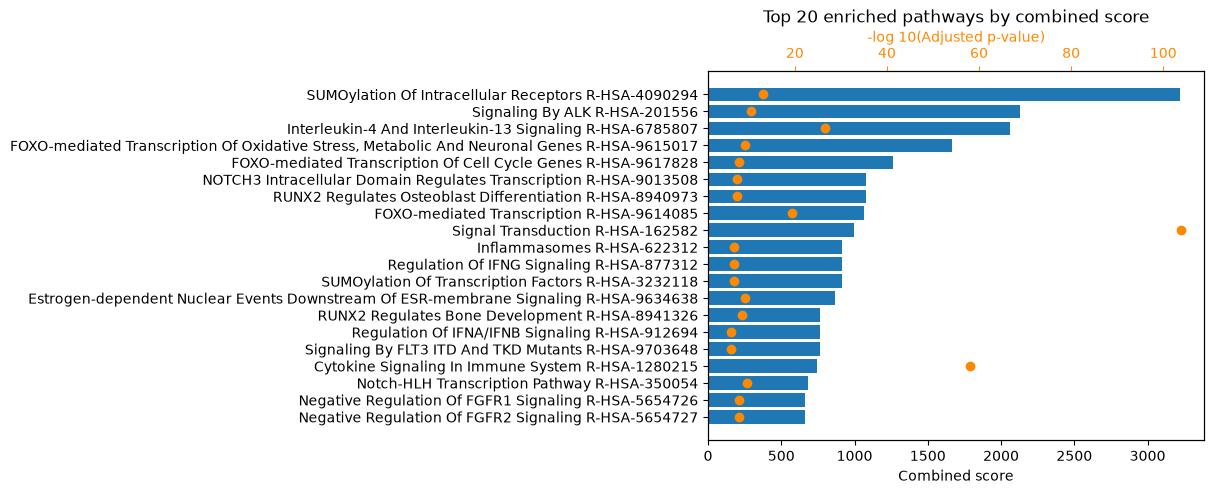

In [13]:
tiedie_results, tiedie_figure = run_enrichment_analysis(network, background, "TieDIE")
print(f"TieDIE enrichment: {len(tiedie_results)} significant terms")
display(tiedie_results.head())
tiedie_figure

## Recap

The run narrowed a broad set of candidate protein pairs down to a confident,
functionally interpretable network:

| Stage | Result |
| --- | --- |
| DDI | domain&ndash;domain interactions |
| DMI (both) | forward + reverse domain&ndash;motif interactions |
| IDR filter | motifs in disordered, binding-competent regions |
| Monte Carlo | over-represented motifs (`seed=0`) |
| TieDie | host&ndash;microbe signalling network (`permute=1000`) |
| Enrichment | over-represented Reactome pathways (HMI + TieDIE) |

The printed counts above are the live numbers from this run. Where to go next:

- the [default notebook](t2_api_basic.md) for the shorter forward-only run,
- the command-line tutorials ([comprehensive](t3_cli_full.md),
  [default](t4_cli_basic.md)) for the same steps from the terminal,
- [Pipeline Concepts](../concepts.md) and the
  [API Reference](../api/index.md) for the details of each module.